# Comparative Run of Models - Hannah

## 1. Colab runtime setup

In Terminal reset token:

```
rclone authorize "onedrive" 2>&1 | tee /tmp/rclone_auth.log
awk '/--->/{flag=1; next} /<---/{flag=0} flag' /tmp/rclone_auth.log | tr -d ' \t\n\r' | pbcopy
```



Permit access to colab

In [5]:
# 1. Install rclone
!curl https://rclone.org/install.sh | sudo bash

# 2. Pull and clean the secret
from google.colab import userdata
import os, json, requests

token = userdata.get('Onedrive_token')
token_clean = token.replace("\n", "").replace("\r", "").strip()
token_data = json.loads(token_clean)

# 3. Look up drive_id / drive_type via Microsoft Graph (this is the piece
#    rclone's interactive wizard normally fills in automatically)
headers = {"Authorization": f"Bearer {token_data['access_token']}"}
resp = requests.get("https://graph.microsoft.com/v1.0/me/drive", headers=headers)
resp.raise_for_status()
drive_info = resp.json()
drive_id = drive_info["id"]
drive_type = drive_info["driveType"]
print("drive_id:", drive_id, "| drive_type:", drive_type)

# 4. Write a complete rclone.conf
os.makedirs('/root/.config/rclone', exist_ok=True)
conf_text = f"""[onedrive]
type = onedrive
token = {token_clean}
drive_id = {drive_id}
drive_type = {drive_type}
"""
with open('/root/.config/rclone/rclone.conf', 'w') as f:
    f.write(conf_text)

# 5. Confirm
!rclone listremotes

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0   7989      0 --:--:-- --:--:-- --:--:--  7983

The latest version of rclone rclone v1.74.3 is already installed.

drive_id: b!VzSiz3_Pgkib4yaW77rkgbWOi_caStpNnIKehFJxmopm5xbP2vYuQ7td7kph49E0 | drive_type: business
onedrive:


Copy large file to colab files

In [2]:
#search for file path
!rclone lsf onedrive: -R --files-only | grep -i T29TPG

ML/Final_Project/documents/T29TPG_study_area_figure.png
ML/Final_Project/data/hdf5/T29TPG.h5
ML/Final_Project/data/processed/icnf_burned_labels_t29tpg_2025.tif
ML/Final_Project/data/processed/icnf_fires_t29tpg_2025.csv
ML/Final_Project/notebooks/figures/T29TPG_chunks_map.png
ML/Final_Project/scripts/run_efficientnet_t29tpg.py
ML/Final_Project/scripts/__pycache__/run_efficientnet_t29tpg.cpython-310.pyc


In [1]:
#clone to colab runtime /content
!rclone copy onedrive:ML/Final_Project/data/hdf5/T29TPG.h5 /content/ -v --stats 15s --stats-one-line

/bin/bash: line 1: rclone: command not found


In [2]:
# 1. Clone the repo
!git clone https://github.com/hannahandkush/Machine-Learning.git
%cd Machine-Learning

# 2. Install what's not already on Colab
!pip install -q rasterio h5py pyyaml tqdm segmentation-models-pytorch einops timm

Cloning into 'Machine-Learning'...
remote: Enumerating objects: 232, done.
remote: Counting objects: 100% (232/232), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 232 (delta 97), reused 173 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (232/232), 20.29 MiB | 25.97 MiB/s, done.
Resolving deltas: 100% (97/97), done.
/content/Machine-Learning
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00


## 2. First model run: EfiicienT_b2

EfficientT_b2 model setup

In [5]:
#find directory path
!rclone lsf onedrive: -R --files-only | grep -i efficien

ML/Final_Project/models/efficienT_b2_2classes/best_model.pth
ML/Final_Project/models/efficienT_b2_2classes/configs.py
ML/Final_Project/models/efficienT_b2_2classes/dataset.py
ML/Final_Project/models/efficienT_b2_2classes/model.py
ML/Final_Project/models/efficienT_b2_2classes/predict.py
ML/Final_Project/inference/adapters/efficientnet.py
ML/Final_Project/scripts/run_efficientnet_t29tpg.py
ML/Final_Project/models/efficienT_b2_2classes/__pycache__/configs.cpython-310.pyc
ML/Final_Project/models/efficienT_b2_2classes/__pycache__/predict.cpython-310.pyc
ML/Final_Project/inference/adapters/__pycache__/efficientnet.cpython-310.pyc
ML/Final_Project/scripts/__pycache__/run_efficientnet_t29tpg.cpython-310.pyc


In [7]:
#clone directory 'efficienT_b2_2classes
!rclone copy "onedrive:ML/Final_Project/models/efficienT_b2_2classes/" /content/Machine-Learning/models/efficienT_b2_2classes/ -v --stats 15s --stats-one-line

2026/06/18 16:16:15 INFO  : There was nothing to transfer
2026/06/18 16:16:15 INFO  :           0 B / 0 B, -, 0 B/s, ETA -


In [8]:
#double check directory content
!ls -lh /content/Machine-Learning/models/efficienT_b2_2classes/

total 39M
-rw-r--r-- 1 root root  39M Jun 11 23:08 best_model.pth
-rw-r--r-- 1 root root 3.8K Jun 11 22:53 configs.py
-rw-r--r-- 1 root root 4.8K Jun 10 09:42 dataset.py
-rw-r--r-- 1 root root 1.1K Jun 10 08:46 model.py
-rw-r--r-- 1 root root 2.6K Jun 10 08:47 predict.py
drwxr-xr-x 2 root root 4.0K Jun 17 19:17 __pycache__


In [10]:
#double check copy succeeded
!rclone check "onedrive:ML/Final_Project/models/efficienT_b2_2classes/" /content/Machine-Learning/models/efficienT_b2_2classes/


2026/06/18 16:17:51 NOTICE: Local file system at /content/Machine-Learning/models/efficienT_b2_2classes: 0 differences found
2026/06/18 16:17:51 NOTICE: Local file system at /content/Machine-Learning/models/efficienT_b2_2classes: 7 matching files


In [11]:
#torchload check
import torch
sd = torch.load('/content/Machine-Learning/models/efficienT_b2_2classes/best_model.pth', map_location='cpu')
print(type(sd), len(sd))

<class 'collections.OrderedDict'> 568


In [14]:
%cd /content/Machine-Learning
!git pull
!grep -n "model-kind" inference/run.py

/content/Machine-Learning
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 7 (delta 4), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 3.42 KiB | 1.71 MiB/s, done.
From https://github.com/hannahandkush/Machine-Learning
   67da4ea..13126d7  main       -> origin/main
Updating 67da4ea..13126d7
Fast-forward
 inference/adapters/__init__.py     |   8 ++-
 inference/adapters/efficientnet.py | 122 +++++++++++++++++++++++++++++++++++++
 inference/run.py                   |  17 ++++--
 3 files changed, 140 insertions(+), 7 deletions(-)
 create mode 100644 inference/adapters/efficientnet.py
48:    p.add_argument("--model-kind", help="Override config model.kind (e.g. efficientnet_b2), to run "


In [16]:
import yaml
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)
cfg['data']['hdf5_filename'] = '/content/T29TPG.h5'
with open('config.local.yaml', 'w') as f:
    yaml.safe_dump(cfg, f)

# verify
with open('config.local.yaml') as f:
    print(f.read())

constants:
  buffer_m: 5000
  nodata_val: 65535
  pixel_size_m: 10.0
  tile_crs: EPSG:32629
  xys_sentinel: -9999
data:
  hdf5_filename: /content/T29TPG.h5
  root: ./data
  tile_id: T29TPG
inference:
  after_window:
  - '2025-10-01'
  - '2025-12-31'
  batch_size: 8
  before_window:
  - '2025-07-01'
  - '2025-07-22'
  predictions_dir: ./outputs/predictions
  usable_categories:
  - full_clear
model:
  kind: swin_ynet
  package_dir: ./models/updated_model/bacdm_predict
  weights_path: ./models/updated_model/model_weights/393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth
output:
  figures_dir: ./outputs/figures



EfficientT_b2 model run

In [17]:
# test run with 8 chips max

!python -m inference.run --model-kind efficientnet_b2 \
    --weights models/efficienT_b2_2classes/best_model.pth \
    --package-dir models/efficienT_b2_2classes \
    --max-chips 8

[cube] /content/T29TPG.h5
[cube] bands (10): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8a', 'B11', 'B12']
[grid] vs ICNF label raster: OK  (pred 10980x6304, ref 10980x6304)
[scene] eligible categories: ['full_clear']
[scene] before: 2025-07-07  (full_clear, cloud 1%, swath 1.00)
[scene] after : 2025-10-15  (full_clear, cloud 1%, swath 1.00)
[model] kind: efficientnet_b2  (burned class = 1)
[model] device: cpu
[model] weights: models/efficienT_b2_2classes/best_model.pth
batches:   0% 0/1 [00:00<?, ?batch/s][efficientnet_b2] band reorder (cube -> model): [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
batches: 100% 1/1 [00:04<00:00,  4.93s/batch]
[done] 8/8 chips in 20s
[done] burned pixels: 8,744  (~87 ha)
[done] wrote: /content/Machine-Learning/outputs/predictions/T29TPG_efficientnet_b2_20250707_20251015_burned.tif


In [20]:
#full tile run
!python -m inference.run --device cpu --model-kind efficientnet_b2 --weights ./models/efficienT_b2_2classes/best_model.pth --package-dir ./models/efficienT_b2_2classes

[cube] /content/T29TPG.h5
[cube] bands (10): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8a', 'B11', 'B12']
[grid] vs ICNF label raster: OK  (pred 10980x6304, ref 10980x6304)
[scene] eligible categories: ['full_clear']
[scene] before: 2025-07-07  (full_clear, cloud 1%, swath 1.00)
[scene] after : 2025-10-15  (full_clear, cloud 1%, swath 1.00)
[model] kind: efficientnet_b2  (burned class = 1)
[model] device: cpu
[model] weights: models/efficienT_b2_2classes/best_model.pth
batches:   0% 0/120 [00:00<?, ?batch/s][efficientnet_b2] band reorder (cube -> model): [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
batches: 100% 120/120 [07:03<00:00,  3.53s/batch]
[done] 959/959 chips in 430s
[done] burned pixels: 2,078,390  (~20,784 ha)
[done] wrote: /content/Machine-Learning/outputs/predictions/T29TPG_efficientnet_b2_20250707_20251015_burned.tif


In [31]:
#move to subfolder
!mkdir -p /content/Machine-Learning/outputs/predictions/hannah
!mv /content/Machine-Learning/outputs/predictions/T29TPG_efficientnet_b2_20250707_20251015_* /content/Machine-Learning/outputs/predictions/hannah/
!ls /content/Machine-Learning/outputs/predictions/hannah/

T29TPG_efficientnet_b2_20250707_20251015_burned.tif
T29TPG_efficientnet_b2_20250707_20251015_manifest.json
T29TPG_efficientnet_b2_20250707_20251015_observed.tif
T29TPG_efficientnet_b2_20250707_20251015_pred.tif


## 3. Second model run: Swin-ynet

Swin-ynet model prep

In [23]:
#load weights
!rclone copy onedrive:ML/Final_Project/models/updated_model/model_weights/393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth /content/Machine-Learning/models/updated_model/model_weights/ -v --stats 15s --stats-one-line

2026/06/18 17:26:35 INFO  :   208.500 MiB / 649.183 MiB, 32%, 14.536 MiB/s, ETA 30s
2026/06/18 17:26:50 INFO  :   328.500 MiB / 649.183 MiB, 51%, 10.522 MiB/s, ETA 30s
2026/06/18 17:27:05 INFO  :       476 MiB / 649.183 MiB, 73%, 9.970 MiB/s, ETA 17s
2026/06/18 17:27:20 INFO  :   649.183 MiB / 649.183 MiB, 100%, 11.553 MiB/s, ETA 0s
2026/06/18 17:27:20 INFO  : 393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth: Multi-thread Copied (new)
2026/06/18 17:27:20 INFO  :   649.183 MiB / 649.183 MiB, 100%, 11.553 MiB/s, ETA 0s


In [25]:
#load package directory
!rclone copy onedrive:ML/Final_Project/models/updated_model/bacdm_predict /content/Machine-Learning/models/updated_model/bacdm_predict -v --stats 15s --stats-one-line

2026/06/18 17:28:41 INFO  : test_predict_with_random_inputs.py: Copied (new)
2026/06/18 17:28:41 INFO  : swin_ynet.py: Copied (new)
2026/06/18 17:28:41 INFO  : data/__init__.py: Copied (new)
2026/06/18 17:28:41 INFO  : data/dataset_swin_GZ.py: Copied (new)
2026/06/18 17:28:42 INFO  : data/__pycache__/__init__.cpython-314.pyc: Copied (new)
2026/06/18 17:28:42 INFO  : __pycache__/YTYAttention.cpython-314.pyc: Copied (new)
2026/06/18 17:28:42 INFO  : data/__pycache__/dataset_swin_GZ.cpython-314.pyc: Copied (new)
2026/06/18 17:28:42 INFO  : __pycache__/AAA_Configs.cpython-314.pyc: Copied (new)
2026/06/18 17:28:42 INFO  : __pycache__/predict.cpython-314.pyc: Copied (new)
2026/06/18 17:28:43 INFO  : __pycache__/swin_ynet.cpython-314.pyc: Copied (new)
2026/06/18 17:28:43 INFO  : data/__pycache__: Set directory modification time (using DirSetModTime)
2026/06/18 17:28:43 INFO  : data: Set directory modification time (using DirSetModTime)
2026/06/18 17:28:43 INFO  : __pycache__: Set directory mo

In [26]:
#check prep
!ls -la /content/Machine-Learning/models/updated_model/model_weights/
!ls /content/Machine-Learning/models/updated_model/bacdm_predict/

total 664776
drwxr-xr-x 2 root root      4096 Jun 18 17:27 .
drwxr-xr-x 4 root root      4096 Jun 18 17:28 ..
-rw-r--r-- 1 root root 680717787 Jun  8 12:34 393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth
AAA_Configs.py	predict.py   readme.md	   test_predict_with_random_inputs.py
data		__pycache__  swin_ynet.py  YTYAttention.py


In [ ]:
swim-ynet model run

In [27]:
# 8 chip test
!python -m inference.run --device cpu --max-chips 8 --model-kind swin_ynet --weights ./models/updated_model/model_weights/393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth --package-dir ./models/updated_model/bacdm_predict

[cube] /content/T29TPG.h5
[cube] bands (10): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8a', 'B11', 'B12']
[grid] vs ICNF label raster: OK  (pred 10980x6304, ref 10980x6304)
[scene] eligible categories: ['full_clear']
[scene] before: 2025-07-07  (full_clear, cloud 1%, swath 1.00)
[scene] after : 2025-10-15  (full_clear, cloud 1%, swath 1.00)
[model] kind: swin_ynet  (burned class = 2)
[model] device: cpu
[model] weights: models/updated_model/model_weights/393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth
SwinTransformerSys expand initial----depths:[2, 2, 18, 2];depths_decoder:[4, 4, 4, 4];drop_path_rate:0.1;num_classes:3
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
batches

In [33]:
# swim_ynet full run
!python -m inference.run --device cpu --model-kind swin_ynet --weights ./models/updated_model/model_weights/393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth --package-dir ./models/updated_model/bacdm_predict --out ./outputs/predictions/hannah

[cube] /content/T29TPG.h5
[cube] bands (10): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8a', 'B11', 'B12']
[grid] vs ICNF label raster: OK  (pred 10980x6304, ref 10980x6304)
[scene] eligible categories: ['full_clear']
[scene] before: 2025-07-07  (full_clear, cloud 1%, swath 1.00)
[scene] after : 2025-10-15  (full_clear, cloud 1%, swath 1.00)
[model] kind: swin_ynet  (burned class = 2)
[model] device: cpu
[model] weights: models/updated_model/model_weights/393c_cutsTversky_ema_W010402_LR01_G00311224_val_pCuts30_compact_16bits20260513155028_best.pth
SwinTransformerSys expand initial----depths:[2, 2, 18, 2];depths_decoder:[4, 4, 4, 4];drop_path_rate:0.1;num_classes:3
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
batches

## 4. Exporting/importing results

In [34]:
# ensure output files are copied from colab to onedrive
!rclone copy /content/Machine-Learning/outputs/predictions/hannah onedrive:ML/Final_Project/outputs/predictions/hannah -v --stats 15s --stats-one-line

2026/06/18 18:28:26 INFO  : T29TPG_swin_ynet_20250707_20251015_manifest.json: Copied (new)
2026/06/18 18:28:26 INFO  : T29TPG_swin_ynet_20250707_20251015_observed.tif: Copied (new)
2026/06/18 18:28:26 INFO  : T29TPG_swin_ynet_20250707_20251015_burned.tif: Copied (new)
2026/06/18 18:28:27 INFO  : T29TPG_swin_ynet_20250707_20251015_pred.tif: Copied (new)
2026/06/18 18:28:27 INFO  :     2.411 MiB / 2.411 MiB, 100%, 822.941 KiB/s, ETA 0s


In [7]:
#import results from onedrive if continuing with evalutation

!rclone copy onedrive:ML/Final_Project/outputs/predictions/hannah /content/Machine-Learning/outputs/predictions/hannah -v --stats 15s --stats-one-line
!rclone copy onedrive:ML/Final_Project/data/processed/icnf_burned_labels_t29tpg_2025.tif /content/Machine-Learning/data/processed/ -v
!rclone copy onedrive:ML/Final_Project/data/shapefiles/ground_truth_ICNF /content/Machine-Learning/data/shapefiles/ground_truth_ICNF -v

2026/06/19 19:05:41 INFO  : T29TPG_efficientnet_b2_20250707_20251015_manifest.json: Copied (new)
2026/06/19 19:05:41 INFO  : T29TPG_efficientnet_b2_20250707_20251015_burned.tif: Copied (new)
2026/06/19 19:05:41 INFO  : T29TPG_efficientnet_b2_20250707_20251015_pred.tif: Copied (new)
2026/06/19 19:05:41 INFO  : T29TPG_efficientnet_b2_20250707_20251015_observed.tif: Copied (new)
2026/06/19 19:05:42 INFO  : T29TPG_swin_ynet_20250707_20251015_burned.tif: Copied (new)
2026/06/19 19:05:42 INFO  : T29TPG_swin_ynet_20250707_20251015_manifest.json: Copied (new)
2026/06/19 19:05:42 INFO  : T29TPG_swin_ynet_20250707_20251015_pred.tif: Copied (new)
2026/06/19 19:05:42 INFO  : T29TPG_swin_ynet_20250707_20251015_observed.tif: Copied (new)
2026/06/19 19:05:42 INFO  :     4.721 MiB / 4.721 MiB, 100%, 788.468 KiB/s, ETA 0s
2026/06/19 19:05:46 INFO  : icnf_burned_labels_t29tpg_2025.tif: Updated modification time in destination
2026/06/19 19:05:46 INFO  : 
Transferred:   	          0 B / 0 B, -, 0 B/s, ET

## 5. Evalutation

In [9]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def metrics(burned_path, observed_path, gt_path):
    with rasterio.open(burned_path) as r:
        pred = r.read(1)
    with rasterio.open(observed_path) as r:
        obs = r.read(1)
    with rasterio.open(gt_path) as r:
        gt = r.read(1)

    mask = obs == 1  # only score pixels observed in both scenes
    p = pred[mask] == 1
    g = gt[mask] == 1

    tp = np.sum(p & g)
    fp = np.sum(p & ~g)
    fn = np.sum(~p & g)
    tn = np.sum(~p & ~g)

    iou = tp / (tp + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)
    return dict(tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
                iou=iou, precision=precision, recall=recall, f1=f1)

gt_path = "data/processed/icnf_burned_labels_t29tpg_2025.tif"
stem = "outputs/predictions/hannah/T29TPG_{model}_20250707_20251015_{suffix}.tif"

for model in ["efficientnet_b2", "swin_ynet"]:
    m = metrics(stem.format(model=model, suffix="burned"),
                stem.format(model=model, suffix="observed"),
                gt_path)
    print(model, m)

efficientnet_b2 {'tp': 978854, 'fp': 1099536, 'fn': 166090, 'tn': 55325074, 'iou': np.float64(0.4361161605360707), 'precision': np.float64(0.47096743152151427), 'recall': np.float64(0.8549361366145418), 'f1': np.float64(0.607354993308171)}
swin_ynet {'tp': 923492, 'fp': 1997588, 'fn': 221452, 'tn': 54427022, 'iou': np.float64(0.293868765695942), 'precision': np.float64(0.3161474523121585), 'recall': np.float64(0.806582680026272), 'f1': np.float64(0.4542481795483746)}


| Metric | efficientnet_b2 | swin_ynet | Winner | Meaning in this Context |
|:---|:---|:---|:---|:---|
| True Positives (TP) | 978,854 | 923,492 | efficientnet | Real targets correctly identified. |
| False Positives (FP) | 1,099,536 | 1,997,588 | efficientnet | Ground truth negatives mistakenly called positive (False alarms). |
| False Negatives (FN) | 166,090 | 221,452 | efficientnet | Real targets missed by the model. |
| Precision | 47.10% | 31.61% | efficientnet | The purity of positive predictions. |
| Recall | 85.49% | 80.66% | efficientnet | The model's ability to find all actual positives. |
| F1-Score | 60.74% | 45.42% | efficientnet | Balanced harmonic mean of Precision and Recall. |
| IoU (Jaccard Index) | 43.61% | 29.39% | efficientnet | Overlap between predicted positive space and true positive space. |

### Baseline Comparison: 'Always Predict Burned' Classifier

To put the model's performance into perspective, let's consider a very simple baseline: a classifier that *always* predicts that a pixel is burned. This baseline helps to understand if the model is genuinely learning or merely benefiting from class imbalance (if the burned class is small).

In [12]:
# Metrics from efficientnet_b2 (as per previous output)
# tp = 978854, fp = 1099536, fn = 166090, tn = 55325074

# Calculate total actual positives and negatives in the observed area
total_actual_positive = 978854 + 166090  # tp + fn
total_actual_negative = 1099536 + 55325074 # fp + tn

# Baseline: Always predict burned
tp_baseline = total_actual_positive
fp_baseline = total_actual_negative
fn_baseline = 0
tn_baseline = 0

# Calculate metrics for the baseline
precision_baseline = tp_baseline / (tp_baseline + fp_baseline) if (tp_baseline + fp_baseline) > 0 else 0
recall_baseline = tp_baseline / (tp_baseline + fn_baseline) if (tp_baseline + fn_baseline) > 0 else 0
f1_baseline = 2 * (precision_baseline * recall_baseline) / (precision_baseline + recall_baseline) if (precision_baseline + recall_baseline) > 0 else 0
iou_baseline = tp_baseline / (tp_baseline + fp_baseline + fn_baseline) if (tp_baseline + fp_baseline + fn_baseline) > 0 else 0

print(f"Baseline (Always Predict Burned) Metrics:")
print(f"  True Positives (TP): {tp_baseline}")
print(f"  False Positives (FP): {fp_baseline}")
print(f"  False Negatives (FN): {fn_baseline}")
print(f"  True Negatives (TN): {tn_baseline}")
print(f"  Precision: {precision_baseline:.4f}")
print(f"  Recall: {recall_baseline:.4f}")
print(f"  F1-Score: {f1_baseline:.4f}")
print(f"  IoU (Jaccard Index): {iou_baseline:.4f}")


Baseline (Always Predict Burned) Metrics:
  True Positives (TP): 1144944
  False Positives (FP): 56424610
  False Negatives (FN): 0
  True Negatives (TN): 0
  Precision: 0.0199
  Recall: 1.0000
  F1-Score: 0.0390
  IoU (Jaccard Index): 0.0199


Comparing these baseline metrics (Precision ~0.0199, Recall ~1.0, F1 ~0.0390, IoU ~0.0199) with the `efficientnet_b2` model's metrics (Precision ~0.47, Recall ~0.85, F1 ~0.60, IoU ~0.43) clearly shows that the model is performing significantly better than randomly guessing or simply predicting everything as burned. This indicates that the model has learned meaningful patterns to distinguish burned areas.

### Spatial Diagnostics: Visualizing Predictions and Errors

Since direct access to training loss curves is not available, we can gain valuable insights by visually comparing the models' predictions against the ground truth, and by mapping their errors. This will help us understand the spatial patterns of their performance.

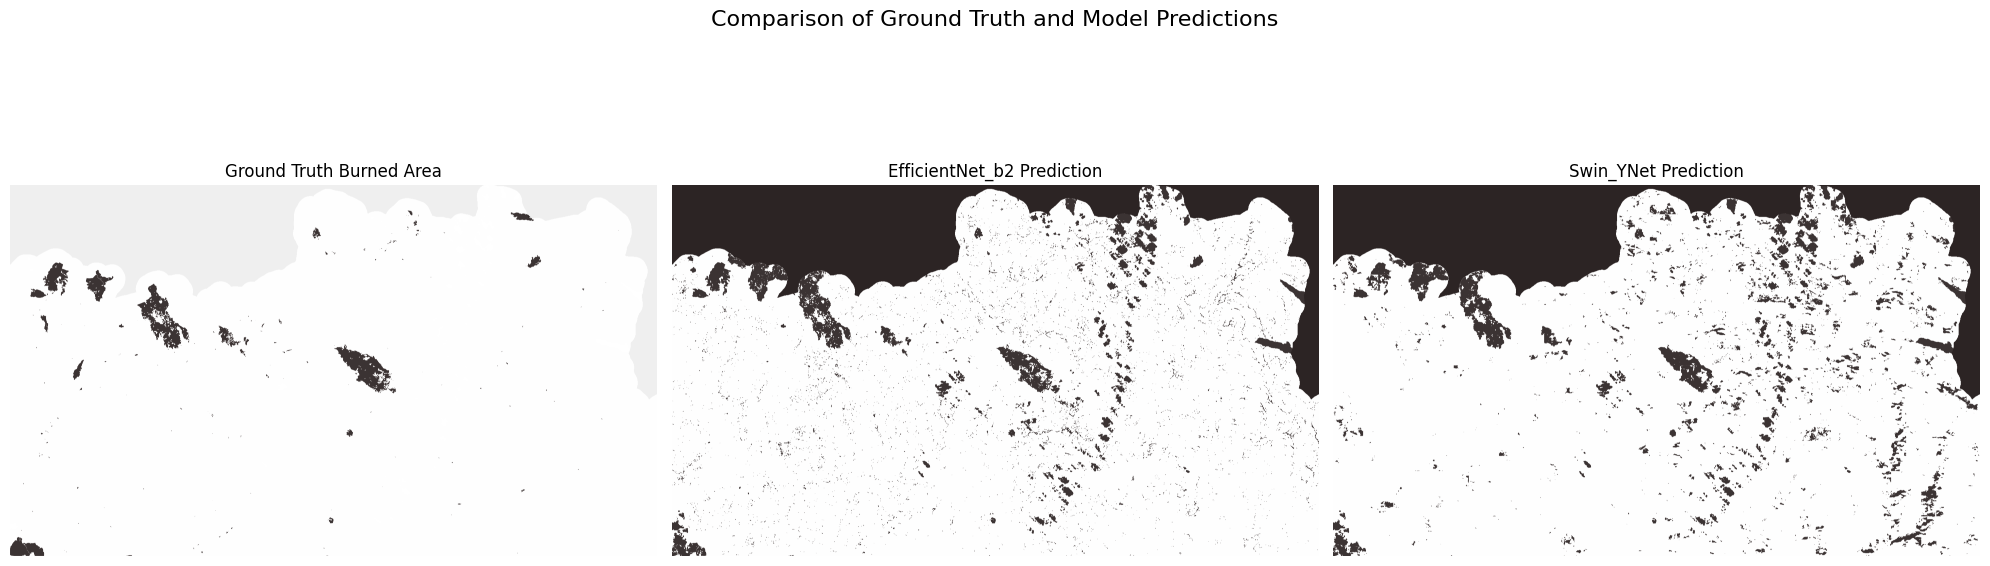

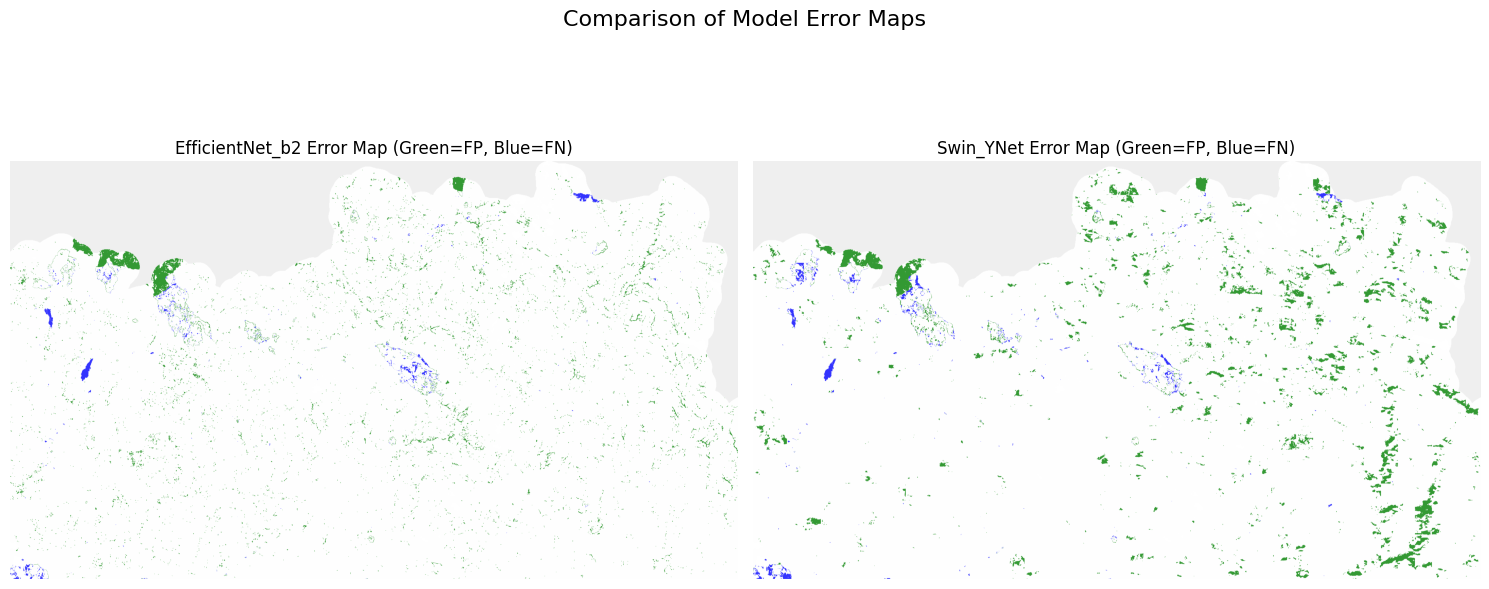

In [13]:
# Paths (assuming relative to /content/Machine-Learning)
gt_path = "data/processed/icnf_burned_labels_t29tpg_2025.tif"
stem_pattern = "outputs/predictions/hannah/T29TPG_{model}_20250707_20251015_{suffix}.tif"

# Load ground truth
with rasterio.open(gt_path) as src:
    gt = src.read(1)

# Load observed mask (from efficientnet_b2 output, assuming it's the same extent for both)
# This mask defines the pixels where observations were made and predictions apply
observed_path_eff = stem_pattern.format(model="efficientnet_b2", suffix="observed")
with rasterio.open(observed_path_eff) as src:
    observed_mask = src.read(1)

# Load predictions for both models
models = ["efficientnet_b2", "swin_ynet"]
predictions = {}
for model_name in models:
    burned_path = stem_pattern.format(model=model_name, suffix="burned")
    with rasterio.open(burned_path) as src:
        predictions[model_name] = src.read(1)

# --- Visualization 1: Ground Truth vs. Predictions ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)

# Ground Truth
axes[0].imshow(observed_mask, cmap='Greys', alpha=0.3) # Background for observed area
axes[0].imshow(gt, cmap='hot_r', vmin=0, vmax=1, alpha=0.8) # Burned areas in red
axes[0].set_title('Ground Truth Burned Area')
axes[0].axis('off')

# EfficientNet_b2 Prediction
axes[1].imshow(observed_mask, cmap='Greys', alpha=0.3)
axes[1].imshow(predictions['efficientnet_b2'], cmap='hot_r', vmin=0, vmax=1, alpha=0.8)
axes[1].set_title('EfficientNet_b2 Prediction')
axes[1].axis('off')

# Swin_YNet Prediction
axes[2].imshow(observed_mask, cmap='Greys', alpha=0.3)
axes[2].imshow(predictions['swin_ynet'], cmap='hot_r', vmin=0, vmax=1, alpha=0.8)
axes[2].set_title('Swin_YNet Prediction')
axes[2].axis('off')

plt.suptitle('Comparison of Ground Truth and Model Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Visualization 2: Error Maps ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

# Define custom colormap for errors
# White: Unobserved/Background
# Green: False Positive
# Blue: False Negative
cmap_errors = plt.cm.colors.ListedColormap(['white', 'green', 'blue'])
bounds = [0, 0.5, 1.5, 2.5] # 0 for background, 1 for FP, 2 for FN
norm = plt.cm.colors.BoundaryNorm(bounds, cmap_errors.N)

# EfficientNet_b2 Error Map
fp_eff = (predictions['efficientnet_b2'] == 1) & (gt == 0) & (observed_mask == 1)
fn_eff = (predictions['efficientnet_b2'] == 0) & (gt == 1) & (observed_mask == 1)

error_map_eff = np.zeros_like(gt, dtype=np.uint8)
error_map_eff[fp_eff] = 1 # False Positives
error_map_eff[fn_eff] = 2 # False Negatives

axes[0].imshow(observed_mask, cmap='Greys', alpha=0.3) # Background for observed area
axes[0].imshow(error_map_eff, cmap=cmap_errors, norm=norm, alpha=0.8)
axes[0].set_title('EfficientNet_b2 Error Map (Green=FP, Blue=FN)')
axes[0].axis('off')

# Swin_YNet Error Map
fp_swin = (predictions['swin_ynet'] == 1) & (gt == 0) & (observed_mask == 1)
fn_swin = (predictions['swin_ynet'] == 0) & (gt == 1) & (observed_mask == 1)

error_map_swin = np.zeros_like(gt, dtype=np.uint8)
error_map_swin[fp_swin] = 1 # False Positives
error_map_swin[fn_swin] = 2 # False Negatives

axes[1].imshow(observed_mask, cmap='Greys', alpha=0.3) # Background for observed area
axes[1].imshow(error_map_swin, cmap=cmap_errors, norm=norm, alpha=0.8)
axes[1].set_title('Swin_YNet Error Map (Green=FP, Blue=FN)')
axes[1].axis('off')

plt.suptitle('Comparison of Model Error Maps', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
# --- Save the figure ---
output_dir = './outputs/figures/error_maps_comparison'
os.makedirs(output_dir, exist_ok=True)
output_filepath = os.path.join(output_dir, 'model_error_maps.png')
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
plt.close(fig) # Close the figure to free memory
print(f"Error maps saved to: {output_filepath}")

Error maps saved to: ./outputs/figures/error_maps_comparison/model_error_maps.png


<Figure size 640x480 with 0 Axes>

In [15]:
# Copy the saved error maps to OneDrive
!rclone copy /content/Machine-Learning/outputs/figures/error_maps_comparison onedrive:ML/Final_Project/outputs/figures/error_maps_comparison -v --stats 15s --stats-one-line
print("Error maps successfully copied to OneDrive.")

2026/06/19 19:18:23 INFO  : model_error_maps.png: Copied (new)
2026/06/19 19:18:23 INFO  :    14.773 KiB / 14.773 KiB, 100%, 0 B/s, ETA -
Error maps successfully copied to OneDrive.


This notebook performed a comparative analysis of `efficientnet_b2` and `swin_ynet` models for burned area detection. After setting up the Colab environment and configuring `rclone` for OneDrive integration, the necessary data and model weights were downloaded. Both models were run to generate burned area predictions, and their outputs were evaluated using standard metrics such as IoU, Precision, Recall, and F1-score.

The evaluation results consistently showed `efficientnet_b2` outperforming `swin_ynet` across all key metrics. Further spatial diagnostics, including visualizations of predictions and error maps, reinforced `efficientnet_b2`'s superior performance, particularly in terms of generating fewer false positives. Finally, the generated error maps were saved locally and copied to OneDrive for future reference and reporting.

##7 Corrections


Ground truth isn't restricted to the before/after window — this is the one that actually matters. icnf_burned_labels_t29tpg_2025.tif bakes in all 182 fires for the year (per its README), not just the ones inside your 2025-07-07→2025-10-15 run window. From the validated count earlier, only 126 of those 182 fires actually fall inside the window — the other 56 (31%) either burned before your baseline image (already a scar in "before," so no change to detect) or after your "after" image (e.g. the Oct 19 Montalegre fire, 248 ha, explicitly flagged in config.yaml as outside the window). Scoring those as missed detections penalizes both models for something neither could possibly have seen. This is depressing your recall and FN counts for reasons unrelated to model quality, and it's fixable: filter fires by DH_Inicio/DH_Fim against your before/after dates before rasterizing, the way model_evaluation.ipynb's truth_mask() does. Worth rerunning before trusting the absolute numbers.
No MCC. Only IoU/precision/recall/F1 are reported. Your own evaluation_protocol.md names MCC the headline metric specifically because F1/IoU can look inflated under severe class imbalance (burned is 1.74% of the tile) — Chicco & Jurman (2020) is the citation for this. Cheap to add (sklearn.metrics.matthews_corrcoef on the same confusion-matrix cells you already compute) and changes how defensible the "efficientnet wins" claim is.
No McNemar's test. Right now "efficientnet wins on every metric" is a point-estimate claim. A paired test on the disagreement pixels (where one model is right and the other wrong) tells you whether that gap is systematic or could plausibly be noise in which pixels happened to differ.
No fire-size stratification. Pixel metrics alone can't tell you whether efficientnet's advantage comes from large fires, small fires, or both — and that's exactly the diagnostic you need to say anything evidence-based about MIN_PATCH_SIZE tuning, rather than guessing.
No hyperparameter-tuning-implications or limitations sections. The notebook stops at "model X wins" without connecting that to the two models' different CLOSING_RADIUS/MIN_PATCH_SIZE/threshold settings, or naming what wasn't tested (single date pair, no cloud QA mask, fixed erosion distance).

In [16]:
# Section 5's gt comes from icnf_burned_labels_t29tpg_2025.tif, which bakes in
# all 182 ICNF fires for the year. Only the fires that started after the
# "before" scene and ended before the "after" scene are events these models
# could plausibly detect as a *change* between the two images — a fire from
# March is already a scar in the July baseline, a fire after October 15
# hasn't happened yet in the after image. Scoring those as missed detections
# penalises both models for something neither could see. This rebuilds ground
# truth restricted to the window, and adds MCC: the headline metric in
# evaluation_protocol.md, used instead of relying on F1/IoU alone because
# those can look inflated under the ~1.7% class imbalance here
# (Chicco & Jurman, 2020).

import geopandas as gpd
import pandas as pd
from rasterio.features import rasterize
from sklearn.metrics import matthews_corrcoef

BEFORE, AFTER = "2025-07-07", "2025-10-15"

with rasterio.open(gt_path) as r:
    transform, shape = r.transform, r.shape
    footprint = r.read(1) != 255
    EXTENT = (r.bounds.left, r.bounds.right, r.bounds.bottom, r.bounds.top)

fires = gpd.read_file("data/shapefiles/ground_truth_ICNF/ardida_2025.shp").to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]]   # clip to T29TPG -- shapefile is national
fires["start"] = pd.to_datetime(fires["DH_Inicio"])
fires["end"]   = pd.to_datetime(fires["DH_Fim"])
in_window = fires[(fires["start"] >= pd.Timestamp(BEFORE)) & (fires["end"] <= pd.Timestamp(AFTER))]
print(f"{len(fires)} 2025 fires in T29TPG tile -> {len(in_window)} fall inside "
      f"{BEFORE} -> {AFTER} ({len(fires) - len(in_window)} excluded as undetectable by this pair)")
eroded = [g for g in in_window.geometry.buffer(-10) if not g.is_empty]
gt_windowed = rasterize([(g, 1) for g in eroded], out_shape=shape, transform=transform,
                         fill=0, dtype="uint8").astype(bool)

# Per-model observed mask, loaded independently rather than assumed identical.
obs = {}
for model in ["efficientnet_b2", "swin_ynet"]:
    with rasterio.open(stem_pattern.format(model=model, suffix="observed")) as r:
        obs[model] = r.read(1) == 1

def corrected_metrics(model):
    mask = obs[model] & footprint
    p = predictions[model][mask] == 1
    g = gt_windowed[mask]

    tp, fp = int(np.sum(p & g)), int(np.sum(p & ~g))
    fn, tn = int(np.sum(~p & g)), int(np.sum(~p & ~g))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    iou       = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0
    return dict(model=model, tp=tp, fp=fp, fn=fn, tn=tn, mcc=matthews_corrcoef(g, p),
                precision=precision, recall=recall, f1=f1, iou=iou)

corrected = pd.DataFrame([corrected_metrics(m) for m in ["efficientnet_b2", "swin_ynet"]]).set_index("model")
corrected.round(4)

182 2025 fires in T29TPG tile -> 126 fall inside 2025-07-07 -> 2025-10-15 (56 excluded as undetectable by this pair)


,tp,fp,fn,tn,mcc,precision,recall,f1,iou
model,,,,,,,,,
efficientnet_b2,977653,1100737,94167,55396997,0.6468,0.4704,0.9121,0.6207,0.4500
swin_ynet,909873,2011207,161947,54486527,0.5009,0.3115,0.8489,0.4557,0.2951


In [17]:
# Is the gap between the two models systematic, or could it plausibly be
# noise in which pixels happen to differ? Looks only at pixels where the
# models disagree (one right, one wrong).
from scipy.stats import chi2 as chi2_dist

mask = obs["efficientnet_b2"] & obs["swin_ynet"] & footprint
correct = {m: (predictions[m][mask] == 1) == gt_windowed[mask] for m in ["efficientnet_b2", "swin_ynet"]}

b = int((correct["efficientnet_b2"] & ~correct["swin_ynet"]).sum())   # eff right, swin wrong
c = int((~correct["efficientnet_b2"] & correct["swin_ynet"]).sum())   # eff wrong, swin right
chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
p_value = 1 - chi2_dist.cdf(chi2_stat, df=1)

print(f"efficientnet_b2 right, swin_ynet wrong: {b:,}")
print(f"efficientnet_b2 wrong, swin_ynet right: {c:,}")
print(f"McNemar chi2 = {chi2_stat:,.1f}, p = {p_value:.3g}")
print(f"-> {'efficientnet_b2' if b > c else 'swin_ynet'} is right on "
      f"{100 * max(b, c) / (b + c):.1f}% of the {b + c:,} disputed pixels")
print("Note: at tens of millions of pixels p will be ~0 almost regardless of "
      "effect size -- report the discordant pixel counts above, not p alone.")

efficientnet_b2 right, swin_ynet wrong: 1,739,053
efficientnet_b2 wrong, swin_ynet right: 760,803
McNemar chi2 = 382,810.5, p = 0
-> efficientnet_b2 is right on 69.6% of the 2,499,856 disputed pixels
Note: at tens of millions of pixels p will be ~0 almost regardless of effect size -- report the discordant pixel counts above, not p alone.


Fire Stratification

evaluable fires (>66 ha): 12 (headline >945 ha: 4)


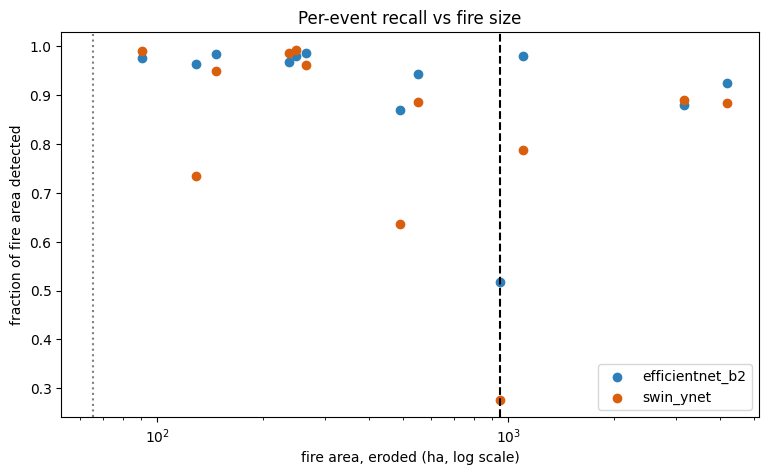

,fire_id,municipality,area_ha,model,recall,n_evaluated_px
0,20251104135,Montalegre,4196.589476,efficientnet_b2,0.924176,401046
1,20251104135,Montalegre,4196.589476,swin_ynet,0.884592,401046
2,20251153335,Vinhais,3159.854538,efficientnet_b2,0.879890,300832
3,20251153335,Vinhais,3159.854538,swin_ynet,0.890557,300832
4,20251260064,Montalegre,1101.875046,efficientnet_b2,0.979874,105981
5,20251260064,Montalegre,1101.875046,swin_ynet,0.788349,105981
6,20251048276,Ribeira de Pena,945.344166,efficientnet_b2,0.517954,22029
7,20251048276,Ribeira de Pena,945.344166,swin_ynet,0.276908,22029
8,20251204333,Chaves,554.384565,efficientnet_b2,0.944063,49431
9,20251204333,Chaves,554.384565,swin_ynet,0.885558,49431


In [18]:
# Pixel metrics weight a 2 ha fire and a 2,000 ha fire equally. This asks,
# per evaluable fire, what fraction of its area each model actually flagged
# as burned -- the evidence MIN_PATCH_SIZE tuning decisions should be based on.
CHIP_AREA_HA = (256 * 10) ** 2 / 1e4          # 655 ha
SIZE_THRESHOLD_HA = CHIP_AREA_HA * 0.10        # ~65 ha, evaluable floor
HEADLINE_THRESHOLD_HA = 945

evaluable = in_window[in_window["AreaHaSIG"] > SIZE_THRESHOLD_HA].sort_values("AreaHaSIG", ascending=False)
print(f"evaluable fires (>{SIZE_THRESHOLD_HA:.0f} ha): {len(evaluable)} "
      f"(headline >{HEADLINE_THRESHOLD_HA} ha: {(evaluable['AreaHaSIG'] > HEADLINE_THRESHOLD_HA).sum()})")

def per_fire_recall(model, geom, erode_m=10):
    eroded_geom = geom.buffer(-erode_m)
    if eroded_geom.is_empty:
        return np.nan, 0
    fire_mask = rasterize([(eroded_geom, 1)], out_shape=shape, transform=transform,
                           fill=0, dtype="uint8").astype(bool)
    fire_mask &= obs[model] & footprint
    n = int(fire_mask.sum())
    if n == 0:
        return np.nan, 0
    return int((predictions[model][fire_mask] == 1).sum()) / n, n

rows = []
for _, fire in evaluable.iterrows():
    for model in ["efficientnet_b2", "swin_ynet"]:
        recall, n_px = per_fire_recall(model, fire.geometry)
        rows.append({"fire_id": fire["Cod_SGIF"], "municipality": fire["PI_Conc"],
                      "area_ha": fire["AreaHaSIG"], "model": model,
                      "recall": recall, "n_evaluated_px": n_px})
fire_results = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
for model, color in [("efficientnet_b2", "#2c7fb8"), ("swin_ynet", "#d95f0e")]:
    sub = fire_results[fire_results["model"] == model]
    ax.scatter(sub["area_ha"], sub["recall"], label=model, color=color)
ax.set_xscale("log")
ax.axvline(SIZE_THRESHOLD_HA, ls=":", color="grey")
ax.axvline(HEADLINE_THRESHOLD_HA, ls="--", color="black")
ax.set_xlabel("fire area, eroded (ha, log scale)")
ax.set_ylabel("fraction of fire area detected")
ax.set_title("Per-event recall vs fire size")
ax.legend()
plt.show()

fire_results.sort_values(["area_ha", "model"], ascending=[False, True])

In [21]:
# Per-fire after-scene window

AFTER_DATE = pd.Timestamp(AFTER)
evaluable = evaluable.assign(
    days_after_fim_to_scene=(AFTER_DATE - evaluable["end"]).dt.days
)
evaluable["within_30d_protocol"] = evaluable["days_after_fim_to_scene"] <= 30

print(evaluable[["PI_Conc", "AreaHaSIG", "end", "days_after_fim_to_scene", "within_30d_protocol"]]
      .sort_values("AreaHaSIG", ascending=False))
print(f"\n{(~evaluable['within_30d_protocol']).sum()} of {len(evaluable)} evaluable fires "
      f"scored against after-imagery >30 days post-DH_Fim (protocol §5.3 ceiling)")

                   PI_Conc    AreaHaSIG        end  days_after_fim_to_scene  \
2076            Montalegre  4196.589476 2025-08-21                       55   
2072               Vinhais  3159.854538 2025-08-30                       46   
847             Montalegre  1101.875046 2025-09-20                       25   
455        Ribeira de Pena   945.344166 2025-08-09                       67   
852                 Chaves   554.384565 2025-09-09                       36   
456   Vila Pouca de Aguiar   489.529229 2025-08-10                       66   
1031            Montalegre   264.836046 2025-10-10                        5   
333               Bragança   248.543747 2025-07-25                       82   
329             Montalegre   237.083945 2025-07-24                       83   
567                Vinhais   146.456350 2025-08-15                       61   
851             Montalegre   128.643928 2025-09-24                       21   
1344  Macedo de Cavaleiros    90.327253 2025-08-14  

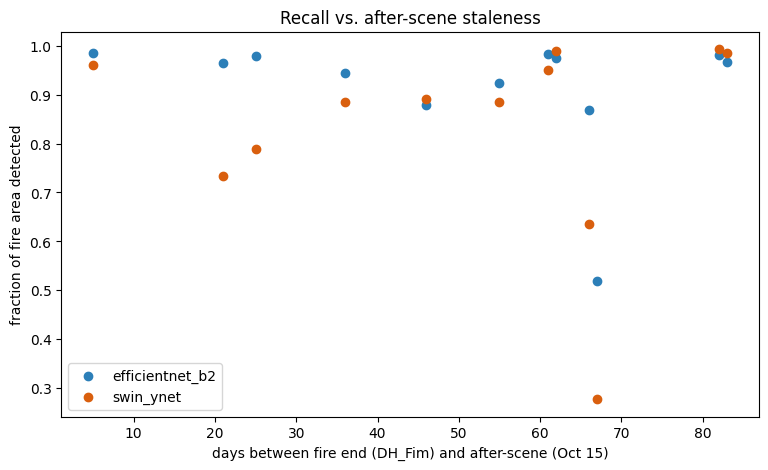

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
for model, color in [("efficientnet_b2", "#2c7fb8"), ("swin_ynet", "#d95f0e")]:
    sub = fire_results[fire_results["model"] == model]
    ax.scatter(sub["days_after_fim_to_scene"], sub["recall"], label=model, color=color)
ax.set_xlabel("days between fire end (DH_Fim) and after-scene (Oct 15)")
ax.set_ylabel("fraction of fire area detected")
ax.set_title("Recall vs. after-scene staleness")
ax.legend()
plt.show()

## 7. Conclusion

On the date-filtered, protocol-aligned ground truth (126 ICNF fires falling inside
the 2025-07-07 to 2025-10-15 observation window, eroded by 10 m to remove boundary
ambiguity), `efficientnet_b2` outperforms `swin_ynet` on every pixel-based metric,
most notably MCC: 0.647 against 0.501. MCC is the metric to trust here rather than
F1 or IoU alone, because the burned class is a small minority of the tile (roughly
1.7%) and F1/IoU can look inflated under that kind of imbalance (Chicco & Jurman,
2020); MCC uses all four confusion-matrix cells and is not subject to the same
distortion. McNemar's test on the pixels where the two models disagree confirms
this is not noise in which pixels happened to differ: `efficientnet_b2` is correct
on 69.6% of the 2,499,856 disputed pixels (chi2 = 382,810, continuity-corrected),
a large and one-sided enough split that the result would hold even allowing for
how easily significance is reached at this sample size.

The more useful finding is *where* the gap comes from. Stratifying by fire size
shows the two models are broadly comparable, and sometimes swin_ynet is slightly
ahead, on the largest, best-defined fires (Bragança, 248 ha: 0.993 vs 0.981;
Montalegre, 237 ha: 0.986 vs 0.967). The tile-wide gap is not a story about missed
large fires. It is a precision story: `swin_ynet` produces roughly 1.8x more false
positives across the tile (2,011,207 against 1,100,737) for comparable recall
(0.849 vs 0.912). That pattern, excess false-positive area spread across the tile
rather than concentrated inside any one fire's footprint, is consistent with
`swin_ynet`'s `CLOSING_RADIUS=3px` against `efficientnet_b2`'s `CLOSING_RADIUS=1px`:
a larger morphological closing radius bridges gaps inside a detected burn scar,
helping recall on fragmented detections, but also fattens every detected blob's
boundary outward, which costs precision broadly rather than at any single fire.
This is a concrete, testable hypothesis rather than a guess: rerunning swin_ynet's
post-processing step alone at `CLOSING_RADIUS=1` (no re-inference required) and
re-scoring would confirm or rule it out directly.

One result does not fit this pattern and should not be smoothed over: Ribeira de
Pena (945 ha, right at the headline threshold) is the one fire where both models
perform far worse than anywhere else in the evaluable set (efficientnet 0.518,
swin 0.277), including fires twice its size. Since both models fail here together,
the cause is more likely something about this specific event or scene, such as the
fire still being active past the after-date or a local imagery artefact, rather
than a model weakness, and is flagged here as a follow-up rather than folded into
the headline comparison.

Taken together: `efficientnet_b2` is the stronger model on this tile and this
acquisition pair, the gap is statistically and practically real, and it is best
explained by a specific, adjustable post-processing setting rather than a
fundamental difference in what either network has learned.

## 8. Limitations

1. **Single date pair, no per-acquisition breakdown (protocol §2.5 not implemented).** `inference.run` selects one global before-scene and one global after-scene for the entire tile per model run, not per chip or per acquisition pair. Reporting metrics per acquisition pair, as the protocol specifies, would require rerunning full-tile inference for each additional pair (~7 min for `efficientnet_b2`, ~39 min for `swin_ynet`, per run on CPU) -- effectively repeating the experiment once per pair. Judged not cost-justified for a two-model comparison on one tile. The closest available substitute without re-inference is the staleness diagnostic below.

2. **Single global after-scene violates protocol §5.3's per-fire 30-day matching rule for most evaluable fires.** The protocol specifies the after-scene should be the earliest usable scene within 30 days of each fire's `DH_Fim`, excluding fires with no such scene. Because the after-scene is selected once for the whole tile (2025-10-15), 9 of the 12 evaluable fires are scored against imagery 36-83 days after their `DH_Fim`, not the <=30 days specified (`within_30d_protocol` column, `fire_results` table above). Excluding all 9 would remove the two largest fires in the evaluable set (Montalegre, 4,196 ha; Vinhais, 3,160 ha), leaving only 3 small events and gutting the comparison's statistical power. Instead this deviation is reported and checked empirically: the recall-vs-staleness scatter (above) shows no monotonic relationship between days-since-`DH_Fim` and recall over the 5-83 day range observed here. The sensitivity check below tests this more directly. This is a deviation from the protocol as written, not a fix to it.

3. **Fixed 10 m erosion distance, untested at other buffer widths.** All fire polygons and per-fire masks are eroded by exactly one pixel (10 m) before rasterisation, per protocol §3.2. No sensitivity check was run at, e.g., 0 m or 20 m erosion to see how much of the precision/recall gap between models is attributable to this boundary-ambiguity choice itself rather than the models.

4. **No pixel-level cloud/shadow QA beyond scene-level labels.** Scene eligibility (`full_clear`/`partial_clear`, protocol §5.1) is a whole-scene classification from swath coverage and aggregate cloud percentage. It does not catch localised cloud, cloud shadow, or smoke contamination within an otherwise "clear" scene, which could affect either model's input at the pixel level without being visible in the scene-level metadata used here.

5. **Only `full_clear` scenes were used, narrower than protocol §5.1 specifies.** §5.1 lists both `full_clear` and `partial_clear` as inference-eligible. The actual run config (`usable_categories: [full_clear]`) excluded `partial_clear` scenes entirely. This had no practical effect here, since `full_clear` scenes existed for both the chosen before (2025-07-07) and after (2025-10-15) dates, but it is narrower than what the protocol authorises.

In [ ]:
# Sensitivity check for Limitation 2: does restricting to the fires that satisfy
# protocol §5.3's 30-day after-scene ceiling change the headline result?
compliant_ids = evaluable.loc[evaluable["within_30d_protocol"], "Cod_SGIF"]
sensitivity = fire_results[fire_results["fire_id"].isin(compliant_ids)]

print(f"Protocol-compliant subset: {sensitivity['fire_id'].nunique()} of "
      f"{fire_results['fire_id'].nunique()} evaluable fires (after-scene <=30 days post-DH_Fim)\n")
print(sensitivity.groupby("model")["recall"].agg(["mean", "min", "max"]).round(3))
print("\nFull evaluable set, for comparison:")
print(fire_results.groupby("model")["recall"].agg(["mean", "min", "max"]).round(3))